In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score

In [2]:
def load_and_decision_tree2(
        test_target, 
        keywords, 
        test_ratio=0.2, 
        target_col="pseudo_class",
        n_estimators=4,
        random_sample=False):

    # --------------------------
    # 1) 訓練データ読み込み
    # --------------------------
    df_train = pd.DataFrame()
    for kw in keywords:
        df1 = pd.read_csv(f"class_data_acc/data_last/data_acc_{kw}_512.csv")
        df_train = pd.concat([df_train, df1], axis=0, ignore_index=True)

    # --------------------------
    # 2) テスト対象人物のデータ
    # --------------------------
    df_test_all = pd.read_csv(f"class_data_acc/data_last/data_acc_{test_target}_512.csv")

    # test_ratio 部分をテスト、それ以外を訓練に加える or 加えない
    if test_ratio > 0:
        n = len(df_test_all)
        n_test = int(n * test_ratio)

        if random_sample:
            df_test = df_test_all.sample(n=n_test, random_state=0)
        else:
            df_test = df_test_all.iloc[:n_test]
        df_test_rest = df_test_all.drop(df_test.index)

        # keywords に test_target を含めれば df_test_rest を train に追加
        if test_target in keywords:
            df_train = pd.concat([df_train, df_test_rest], axis=0, ignore_index=True)

    else:
        df_test = df_test_all

    # --------------------------
    # 3) 本物ラベル（acc_label）読み込み
    # --------------------------
    df_real_label = pd.read_csv(f"../前処理/label_data/label_{test_target}.csv")

    # --- 【重要】ここでラベルと特徴量の行数を強制的に揃える ---
    min_len_all = min(len(df_test_all), len(df_real_label))
    df_real_label = df_real_label.iloc[:min_len_all].reset_index(drop=True)
    df_test_all = df_test_all.iloc[:min_len_all].reset_index(drop=True)

    # test_ratio > 0 の場合はテストの長さにも合わせる
    if test_ratio > 0:
        min_len_test = min(len(df_test), len(df_real_label))
        df_test = df_test.iloc[:min_len_test].reset_index(drop=True)
        df_real_label_test = df_real_label.iloc[:min_len_test].reset_index(drop=True)
    else:
        df_real_label_test = df_real_label.copy().reset_index(drop=True)

    # --------------------------
    # 4) 学習用前処理
    # --------------------------
    if target_col in df_train.columns:
        df_train = df_train.dropna(subset=[target_col]).reset_index(drop=True)
    if target_col in df_test.columns:
        df_test = df_test.dropna(subset=[target_col]).reset_index(drop=True)

    feature_cols = [c for c in df_train.columns if c != target_col]

    X_train = df_train[feature_cols].values
    y_train = df_train[target_col].values

    X_test = df_test[feature_cols].values
    y_test = df_test[target_col].values

    # --------------------------
    # 5) モデル学習
    # --------------------------
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=10,
        random_state=15,
        class_weight="balanced"
    )
    model.fit(X_train, y_train)

    # --------------------------
    # 6) 評価
    # --------------------------
    pred = model.predict(X_test)

    # --- 本物ラベルをテスト長に合わせる ---
    min_len_eval = min(len(pred), len(df_real_label_test))
    pred = pred[:min_len_eval]
    y_test = y_test[:min_len_eval]
    real_labels = df_real_label_test["acc_label"].values[:min_len_eval]

    acc = (pred == y_test).mean()
    acc_real = accuracy_score(real_labels, pred)

    print(f"Accuracy on real labels: {acc_real:.4f}")
    print(classification_report(real_labels, pred))

    return model, acc, pred, X_test, y_test, real_labels, feature_cols, acc_real


In [3]:
def plot_variables(df, variables,y_test,y_label,title=''):
    # color_map = {0: 'blue', 1: 'orange', 2: 'green', 3: 'red', 4: 'purple'}
    color_map = {0: 'blue', 1: 'orange', 4: 'green', 3: 'red', 2: 'purple', 5: 'brown'}

    cluster_series = y_test.values
    change_points = [0] + list(np.where(cluster_series[1:] != cluster_series[:-1])[0] + 1) + [len(df)]

    for var in variables:
        plt.figure(figsize=(20, 2))

        for start, end in zip(change_points[:-1], change_points[1:]):
            cluster = cluster_series[start]

            # NaN のクラスタはスキップ
            if pd.isna(cluster):
                continue

            color = color_map.get(cluster, 'gray')
            plt.plot(df.index[start:end], df[var].iloc[start:end], color=color)

        plt.xlabel('index')
        plt.ylabel(var)
        plt.title(f'{var} with Cluster {title}')
        plt.grid()
        plt.show()

    cluster_series = y_label.values
    change_points = [0] + list(np.where(cluster_series[1:] != cluster_series[:-1])[0] + 1) + [len(df)]

    for var in variables:
        plt.figure(figsize=(20, 2))

        for start, end in zip(change_points[:-1], change_points[1:]):
            cluster = cluster_series[start]

            # NaN のクラスタはスキップ
            if pd.isna(cluster):
                continue

            color = color_map.get(cluster, 'gray')
            plt.plot(df.index[start:end], df[var].iloc[start:end], color=color)

        plt.xlabel('index')
        plt.ylabel(var)
        plt.title(f'{var} with Label {title}')
        plt.grid()
        plt.show()

from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt

keywords = ['kannno1', 'sato1', 'nishi2','mori1','mori2','tanaka1','tanaka2','tuji2']
test_target = 'tuji2'

test_ratios = [1]

# ここを自由に変える
n_estimators_list = [4, 10, 100]

# 結果格納
acc_results = {n: [] for n in n_estimators_list}
f1_results  = {n: [] for n in n_estimators_list}

for n_est in n_estimators_list:
    print(f"===== n_estimators = {n_est} =====")

    for test_target in keywords:
        model, acc, pred, X_test, y_test, real_labels, feature_cols, acc_real = load_and_decision_tree2(
            test_target=test_target,
            keywords=keywords,
            test_ratio=test_ratios[0],
            target_col="class",
            n_estimators=n_est
        )

        # real accuracy
        acc_results[n_est].append(acc_real)

        # F1-score (real label)
        f1_val = f1_score(real_labels, pred, average="weighted")
        f1_results[n_est].append(f1_val)

        print(f"[n={n_est}, ratio={test_ratios[0]}] acc_real={acc_real:.3f}, f1={f1_val:.3f}")


In [4]:
# subjects = [
#     'kannno1','sato1', 'nishi2',
#     'mori1', 'mori2',
#     'tanaka1', 'tanaka2',
#     'tuji1'
# ]

# subjects = ['kannno1', 'sato1', 'nishi2', 'mori1','mori2',"tanaka1","tanaka2","tuji1","tuji2","okawa1","okawa2","maeda1","maeda2"]
subjects = ['kannno1', 'sato1', 'nishi2', 'mori1','mori2',"tanaka1","tanaka2","tuji1","tuji2","okawa1","okawa2"]

# subjects = ["okawa2"]
n_estimators_list = [4,10,100]

acc_results = {n: [] for n in n_estimators_list}
f1_results  = {n: [] for n in n_estimators_list}
test_subjects = []

for test_target in subjects:
    train_keywords = [s for s in subjects if s != test_target]
    test_subjects.append(test_target)

    for n_est in n_estimators_list:
        model, acc, pred, X_test, y_test, real_labels, feature_cols, acc_real = load_and_decision_tree2(
            test_target=test_target,
            keywords=train_keywords,   # ← ここが超重要
            test_ratio=1.0,
            target_col="xgb_class",
            # target_col="rf_class",
            n_estimators=n_est
        )

        acc_results[n_est].append(acc_real)
        f1_val = f1_score(real_labels, pred, average="macro")
        f1_results[n_est].append(f1_val)

        print(f"[test={test_target}, n={n_est}] acc={acc_real:.3f}, f1={f1_val:.3f}")


Accuracy on real labels: 0.9141
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     10561
           1       0.97      0.57      0.72      2509

    accuracy                           0.91     13070
   macro avg       0.94      0.78      0.83     13070
weighted avg       0.92      0.91      0.90     13070

[test=kannno1, n=4] acc=0.914, f1=0.834
Accuracy on real labels: 0.9247
              precision    recall  f1-score   support

           0       0.92      0.99      0.96     10561
           1       0.96      0.63      0.76      2509

    accuracy                           0.92     13070
   macro avg       0.94      0.81      0.86     13070
weighted avg       0.93      0.92      0.92     13070

[test=kannno1, n=10] acc=0.925, f1=0.859
Accuracy on real labels: 0.9193
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     10561
           1       0.96      0.61      0.74      2509

    a

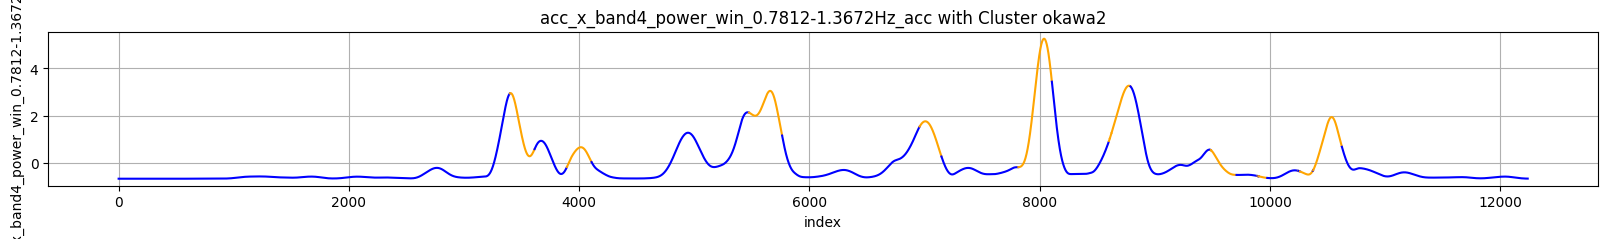

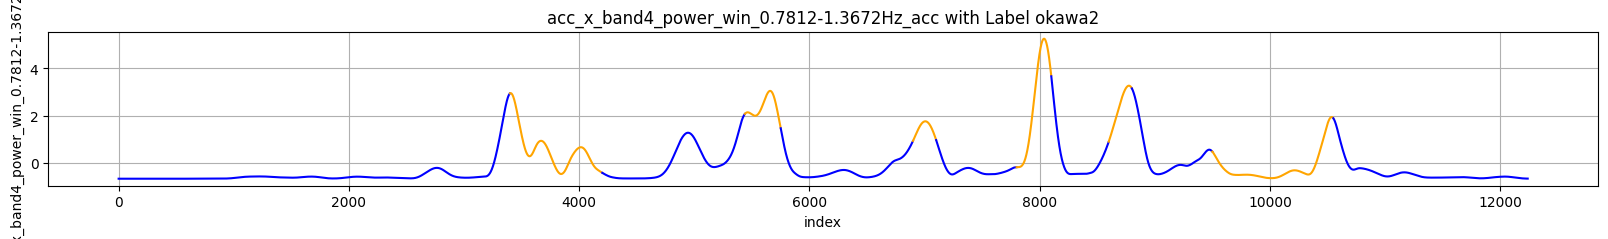

In [5]:
plot_variables(pd.read_csv(f"class_data_acc/data_last/data_acc_{test_target}_512.csv"), 
               variables=['acc_x_band4_power_win_0.7812-1.3672Hz_acc'],
               y_test=pd.Series(pred), 
               y_label=pd.read_csv(f"../前処理/label_data/label_{test_target}.csv")["acc_label"],
               title=test_target
              )

In [6]:
# 9000~11000の区間で、グラフ表示



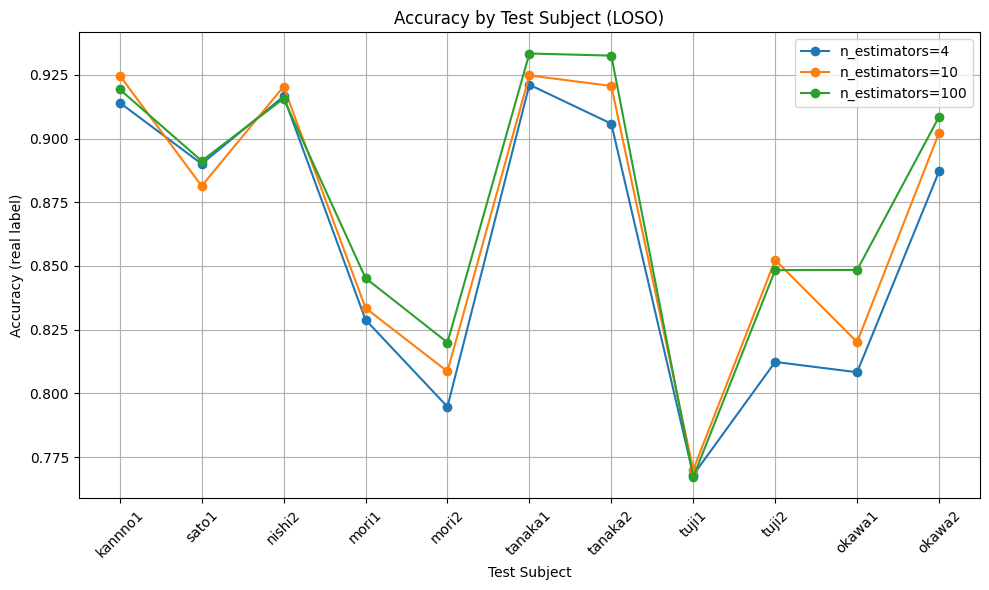

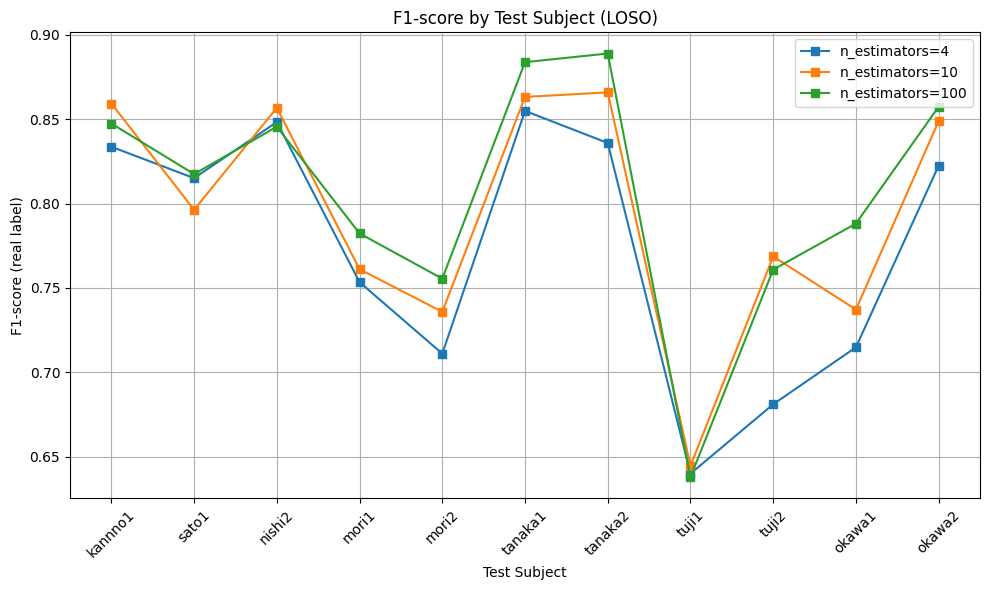

In [7]:
plt.figure(figsize=(10, 6))

for n_est in n_estimators_list:
    plt.plot(
        test_subjects,
        acc_results[n_est],
        marker='o',
        label=f'n_estimators={n_est}'
    )

plt.xlabel('Test Subject')
plt.ylabel('Accuracy (real label)')
plt.title('Accuracy by Test Subject (LOSO)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

for n_est in n_estimators_list:
    plt.plot(
        test_subjects,
        f1_results[n_est],
        marker='s',
        label=f'n_estimators={n_est}'
    )

plt.xlabel('Test Subject')
plt.ylabel('F1-score (real label)')
plt.title('F1-score by Test Subject (LOSO)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [8]:
records = []

for test_target in subjects:
    pool = [s for s in subjects if s != test_target]  # 12人

    for train_one in pool:  # ← 全探索（12通り）
        for n_est in n_estimators_list:
            model, acc, pred, X_test, y_test, real_labels, feature_cols, acc_real = load_and_decision_tree2(
                test_target=test_target,
                keywords=[train_one],     # k=1
                test_ratio=1.0,
                # target_col="rf_class",
                target_col="xgb_class",
                n_estimators=n_est,
                random_sample=False
            )

            f1_val = f1_score(real_labels, pred, average="macro", zero_division=0)

            records.append({
                "test_target": test_target,
                "train_one": train_one,
                "n_estimators": n_est,
                "acc_real": acc_real,
                "f1_macro": f1_val
            })

df_k1 = pd.DataFrame(records)

# 集約例：n_estimatorsごとに平均±標準偏差（全テスト者×全訓練者で）
summary_k1 = (df_k1.groupby("n_estimators")
              .agg(f1_mean=("f1_macro","mean"),
                   f1_std=("f1_macro","std"),
                   acc_mean=("acc_real","mean"),
                   acc_std=("acc_real","std"),
                   n=("f1_macro","count"))
              .reset_index()
              .sort_values("n_estimators"))

print(summary_k1)


Accuracy on real labels: 0.8266
              precision    recall  f1-score   support

           0       0.82      1.00      0.90     10561
           1       1.00      0.10      0.18      2509

    accuracy                           0.83     13070
   macro avg       0.91      0.55      0.54     13070
weighted avg       0.86      0.83      0.76     13070

Accuracy on real labels: 0.8211
              precision    recall  f1-score   support

           0       0.82      1.00      0.90     10561
           1       1.00      0.07      0.13      2509

    accuracy                           0.82     13070
   macro avg       0.91      0.53      0.51     13070
weighted avg       0.85      0.82      0.75     13070

Accuracy on real labels: 0.8243
              precision    recall  f1-score   support

           0       0.82      1.00      0.90     10561
           1       1.00      0.08      0.16      2509

    accuracy                           0.82     13070
   macro avg       0.91      0.5

In [9]:
import pandas as pd
import numpy as np

summary = []
# 訓練者多い版
for n_est in n_estimators_list:
    summary.append({
        "n_estimators": n_est,
        # "Mean Accuracy": np.mean(acc_results[n_est]),
        "Mean F1-score": np.mean(f1_results[n_est]),
        "Std F1-score": np.std(f1_results[n_est]),
        "min F1-score": np.min(f1_results[n_est]),
        "max F1-score": np.max(f1_results[n_est]),
    })

df_summary = pd.DataFrame(summary)
print(df_summary)

summary_subject = []
for i, test_target in enumerate(subjects):
    record = {"test_target": test_target}
    for n_est in n_estimators_list:
        record[f"f1_score(n={n_est})"] = f1_results[n_est][i]
    summary_subject.append(record)
df_summary_subject = pd.DataFrame(summary_subject)
print(df_summary_subject)

   n_estimators  Mean F1-score  Std F1-score  min F1-score  max F1-score
0             4       0.773682      0.072650      0.639838      0.854954
1            10       0.794326      0.068684      0.644455      0.865927
2           100       0.805930      0.069257      0.637813      0.888966
   test_target  f1_score(n=4)  f1_score(n=10)  f1_score(n=100)
0      kannno1       0.833684        0.859292         0.847438
1        sato1       0.815065        0.796310         0.817464
2       nishi2       0.848357        0.856787         0.845576
3        mori1       0.753395        0.761079         0.782292
4        mori2       0.711024        0.735807         0.755479
5      tanaka1       0.854954        0.863225         0.883832
6      tanaka2       0.835908        0.865927         0.888966
7        tuji1       0.639838        0.644455         0.637813
8        tuji2       0.681015        0.768670         0.760826
9       okawa1       0.714773        0.737159         0.788130
10      okawa2 

    index test_target  f1_score(n=4)  f1_score(n=10)  f1_score(n=100)
0       6     tanaka2       0.835908        0.865927         0.888966
1       5     tanaka1       0.854954        0.863225         0.883832
2       0     kannno1       0.833684        0.859292         0.847438
3       2      nishi2       0.848357        0.856787         0.845576
4      10      okawa2       0.822490        0.848878         0.857419
5       1       sato1       0.815065        0.796310         0.817464
6       8       tuji2       0.681015        0.768670         0.760826
7       3       mori1       0.753395        0.761079         0.782292
8       9      okawa1       0.714773        0.737159         0.788130
9       4       mori2       0.711024        0.735807         0.755479
10      7       tuji1       0.639838        0.644455         0.637813


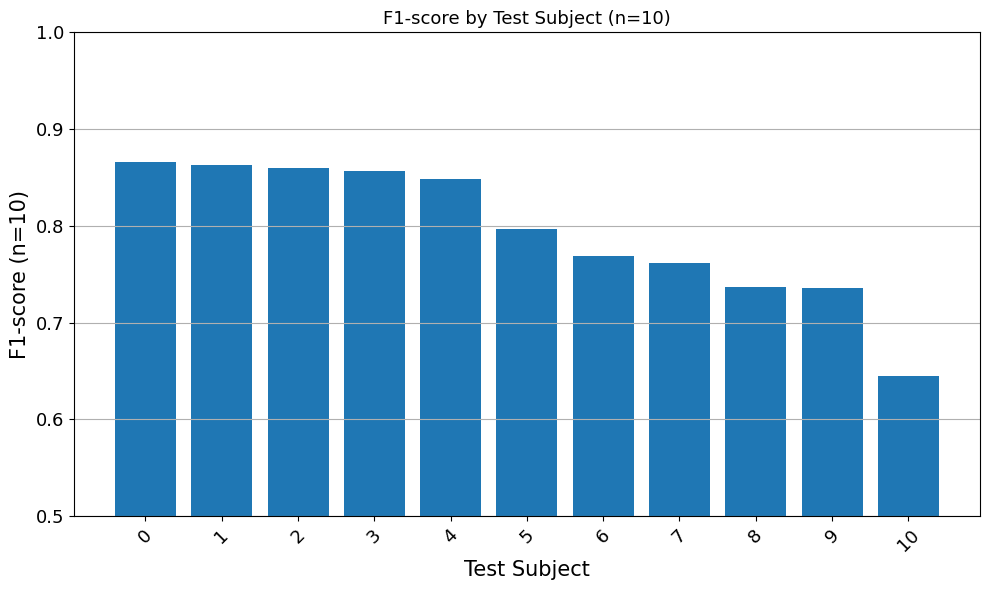

In [10]:
# df_summary_subjectをn=10でソートして表示
df_summary_subject_sorted = df_summary_subject.sort_values(by='f1_score(n=10)', ascending=False,).reset_index()
print(df_summary_subject_sorted)

# ソート後でn=10の棒グラフplot
plt.figure(figsize=(10, 6))
# plt.bar(df_summary_subject_sorted['test_target'], df_summary_subject_sorted['f1_score(n=10)'])
plt.bar(df_summary_subject_sorted.index, df_summary_subject_sorted['f1_score(n=10)'])
plt.xlabel('Test Subject',fontsize=15)
plt.ylabel('F1-score (n=10)',fontsize=15)
plt.title('F1-score by Test Subject (n=10)',fontsize=13)
plt.xticks(df_summary_subject_sorted["index"], rotation=45, fontsize=13)
plt.yticks(fontsize=13)
plt.ylim(0.5, 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

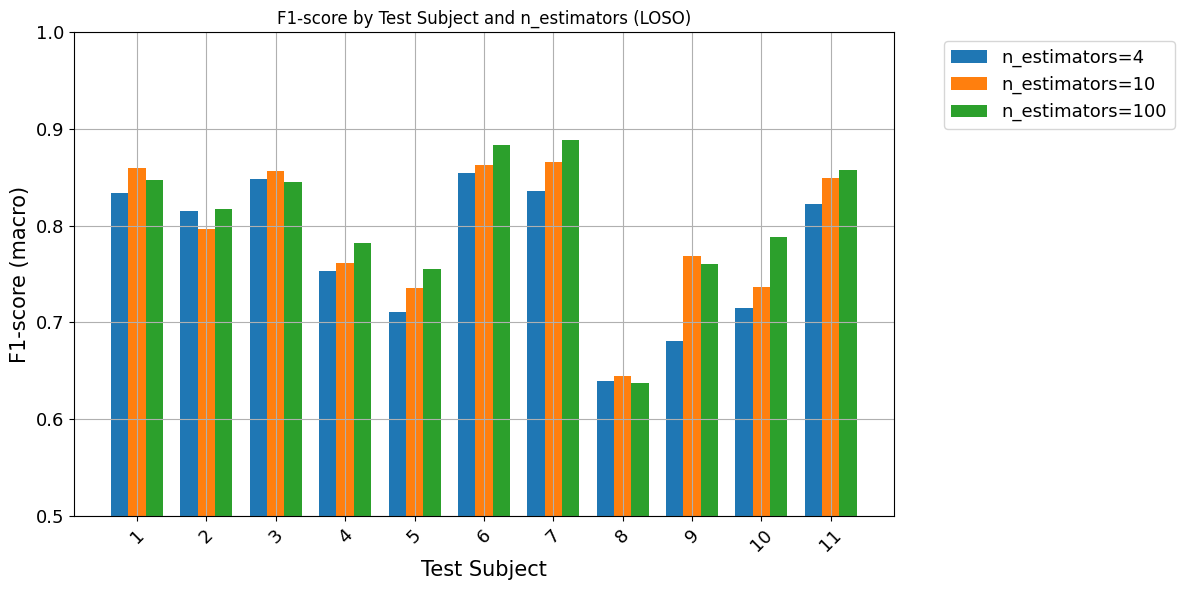

In [11]:
# n_estimators別F1（macro）を訓練者ごとに表示棒グラフでプロット

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
bar_width = 0.25
for i, n_est in enumerate(n_estimators_list):
    plt.bar(
        np.arange(len(subjects)) + i * bar_width,
        [f1_results[n_est][j] for j in range(len(subjects))],
        width=bar_width,
        label=f'n_estimators={n_est}'
    )
plt.xlabel('Test Subject', fontsize=15)
plt.ylabel('F1-score (macro)', fontsize=15)
plt.title('F1-score by Test Subject and n_estimators (LOSO)')

plt.xticks(np.arange(len(subjects)) + bar_width, range(1, len(subjects)+1), rotation=45, fontsize=13)
plt.yticks(fontsize=13)
# legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=13)
plt.ylim(0.5, 1)
plt.grid(True)
plt.tight_layout()
plt.show()



In [12]:
# 訓練者少ない版 (k=1)
summaryk1 = []

for n_est in n_estimators_list:
    summaryk1.append({
        "n_estimators": n_est,
        "Mean F1-score": df_k1[df_k1["n_estimators"]==n_est]["f1_macro"].mean(),
        "Std F1-score": df_k1[df_k1["n_estimators"]==n_est]["f1_macro"].std(),
        "min F1-score": df_k1[df_k1["n_estimators"]==n_est]["f1_macro"].min(),
        "max F1-score": df_k1[df_k1["n_estimators"]==n_est]["f1_macro"].max(),
    })
df_summary_k1 = pd.DataFrame(summaryk1)
print(df_summary_k1)

   n_estimators  Mean F1-score  Std F1-score  min F1-score  max F1-score
0             4       0.582843      0.090569      0.425232      0.795872
1            10       0.590680      0.097620      0.404568      0.800141
2           100       0.601834      0.100817      0.402058      0.838378


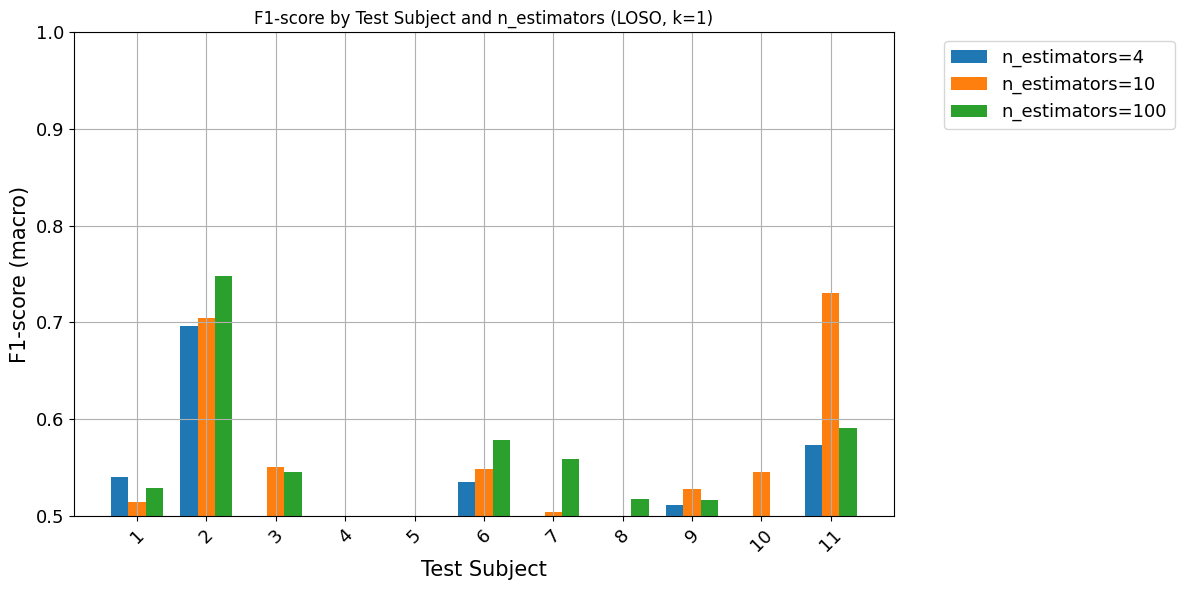

In [13]:
# n_estimators別F1（macro）を訓練者ごとに表示棒グラフでプロット (k=1)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
bar_width = 0.25
for i, n_est in enumerate(n_estimators_list):
    f1_values = []
    for test_target in subjects:
        f1_subset = df_k1[(df_k1["n_estimators"]==n_est) & (df_k1["test_target"]==test_target)]["f1_macro"]
        f1_values.append(f1_subset.values[0] if not f1_subset.empty else 0)
    plt.bar(
        np.arange(len(subjects)) + i * bar_width,
        f1_values,
        width=bar_width,
        label=f'n_estimators={n_est}'
    )
plt.xlabel('Test Subject', fontsize=15)
plt.ylabel('F1-score (macro)', fontsize=15)
plt.title('F1-score by Test Subject and n_estimators (LOSO, k=1)')
# x軸のラベルはsubjectではなく、1,2,3,..にする
plt.xticks(np.arange(len(subjects)) + bar_width, range(1, len(subjects)+1), rotation=45, fontsize=13)
plt.yticks(fontsize=13)
# legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=13)
plt.ylim(0.5, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

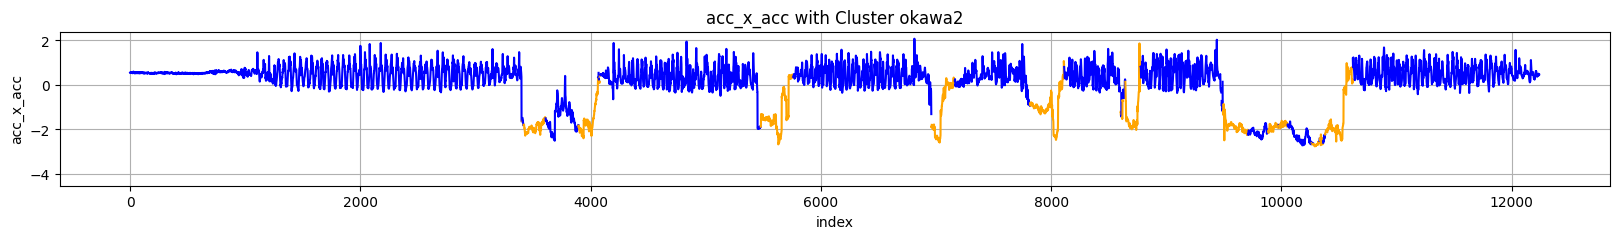

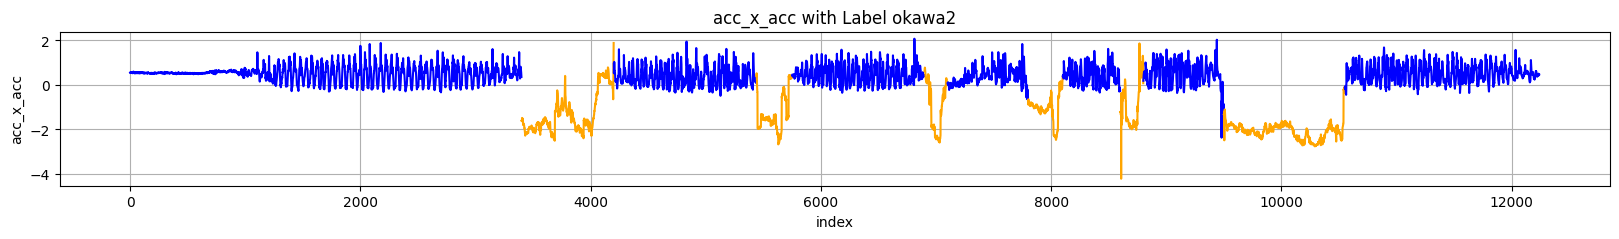

In [14]:
# convert X_test (numpy array) back to DataFrame so plot_variables can use column names and .index
df_test = pd.DataFrame(X_test, columns=feature_cols)

# ensure y_test and real_labels are pandas Series so .values works inside plot_variables
y_test_series = pd.Series(y_test)
real_labels_series = pd.Series(real_labels)

# call the plotting function; use a valid column name and avoid positional-after-keyword error
plot_variables(
    df=df_test,
    variables=['acc_x_acc'],   # choose a valid column name from feature_cols
    y_test=y_test_series,
    y_label=real_labels_series,
    title=test_target
)

In [15]:
def _load_feature_df(kw, window=512, base_dir="class_data_acc/data_last"):
    """
    例: class_data_acc/data_last/data_acc_{kw}_512.csv を読む
    """
    path = os.path.join(base_dir, f"data_acc_{kw}_{window}.csv")
    return pd.read_csv(path)


def _load_real_labels(kw, label_dir="../前処理/label_data"):
    """
    例: ../前処理/label_data/label_{kw}.csv を読む
    acc_label 列を想定
    """
    path = os.path.join(label_dir, f"label_{kw}.csv")
    return pd.read_csv(path)


def _make_test_split_indices(n, test_ratio, random_sample, rng):
    """
    テストに使う行インデックスを返す（ラベル同期用）
    """
    if test_ratio <= 0:
        return np.arange(n)

    n_test = int(n * test_ratio)
    n_test = max(1, n_test)

    if random_sample:
        # ラベルとズレないように「インデックス」をサンプルする
        idx = rng.choice(n, size=n_test, replace=False)
        idx.sort()
        return idx
    else:
        return np.arange(n_test)


def evaluate_trainersize_loso(
    keywords_all,
    k_list,
    *,
    window=512,
    test_ratio=0.2,
    # target_col="rf_class",
    target_col="xgb_class",
    n_estimators=10,
    max_depth=10,
    class_weight="balanced",
    random_sample_test=False,
    n_trials=20,
    seed=0,
    base_dir="class_data_acc/data_last",
    label_dir="../前処理/label_data",
    average="macro",   # F1のaverage
    verbose=True
):
    """
    6.4用:
      - LOSO: test_target を1人ずつ回す
      - 訓練者人数 k を変える
      - 各kで、訓練者集合をランダムに n_trials 回サンプルして平均±分散を見る
      - 評価は real label (acc_label) vs pred の F1 / Accuracy

    返り値:
      results_df: 各 (test_target, k, trial) の生結果
      summary_df: kごとの平均・標準偏差（全test_target集約）
      per_test_summary_df: (test_target, k) ごとの平均・標準偏差
    """
    rng_global = np.random.RandomState(seed)

    records = []

    # 先に全員分のデータをキャッシュ（読み込み回数削減）
    feat_cache = {}
    label_cache = {}

    for kw in keywords_all:
        feat_cache[kw] = _load_feature_df(kw, window=window, base_dir=base_dir)
        label_cache[kw] = _load_real_labels(kw, label_dir=label_dir)

    for test_target in keywords_all:
        others = [kw for kw in keywords_all if kw != test_target]
        if len(others) == 0:
            continue

        df_test_all = feat_cache[test_target].copy()
        df_real_label = label_cache[test_target].copy()

        # --- 行数整合（あなたの方針を踏襲） ---
        min_len_all = min(len(df_test_all), len(df_real_label))
        df_test_all = df_test_all.iloc[:min_len_all].reset_index(drop=True)
        df_real_label = df_real_label.iloc[:min_len_all].reset_index(drop=True)

        # --- テスト行インデックス作成（ラベル同期が本質） ---
        rng_test = np.random.RandomState(rng_global.randint(0, 10**9))
        test_idx = _make_test_split_indices(
            n=min_len_all,
            test_ratio=test_ratio,
            random_sample=random_sample_test,
            rng=rng_test
        )

        # テストデータ＆本物ラベル（インデックス同期）
        df_test = df_test_all.iloc[test_idx].reset_index(drop=True)
        real_labels = df_real_label["acc_label"].iloc[test_idx].to_numpy()

        # pseudo_class 欠損処理（あなたの実装に合わせる）
        if target_col in df_test.columns:
            df_test = df_test.dropna(subset=[target_col]).reset_index(drop=True)
            # real_labels も同じ行削除に合わせる
            # dropnaで落ちた分の行を反映するため、元の df_test の行数変化を追う必要がある
            # ここでは「dropna後の行数に合わせて先頭から切る」ではなく、より安全に同期させる:
            valid_mask = ~pd.isna(df_test_all.iloc[test_idx][target_col].reset_index(drop=True))
            real_labels = real_labels[valid_mask.to_numpy()]

        # testの特徴量列は train に合わせるので、ここでは保持だけしておく
        if verbose:
            print(f"\n[Test] {test_target}  test_n={len(df_test)}  real_label_n={len(real_labels)}")

        for k in k_list:
            if k <= 0:
                continue
            if k > len(others):
                # kが大きすぎるときはスキップ（または len(others) に丸めてもいいが、論文ならスキップが正直）
                if verbose:
                    print(f"  - skip k={k} (only {len(others)} others)")
                continue

            for trial in range(n_trials):
                rng = np.random.RandomState(rng_global.randint(0, 10**9))
                train_keys = list(rng.choice(others, size=k, replace=False))

                # --- 訓練データ作成 ---
                df_train = pd.concat([feat_cache[kw] for kw in train_keys], axis=0, ignore_index=True)

                # 欠損除去
                if target_col in df_train.columns:
                    df_train = df_train.dropna(subset=[target_col]).reset_index(drop=True)

                # 特徴量列
                feature_cols = [c for c in df_train.columns if c != target_col]

                # train/test を同じ列で揃える（欠ける列は0埋め）
                X_train = df_train.reindex(columns=feature_cols, fill_value=0).to_numpy()
                y_train = df_train[target_col].to_numpy()

                X_test = df_test.reindex(columns=feature_cols, fill_value=0).to_numpy()

                # --- 学習 ---
                model = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    random_state=15,
                    class_weight=class_weight,
                )
                model.fit(X_train, y_train)

                # --- 推定 ---
                pred = model.predict(X_test)

                # --- 評価（本物ラベル基準） ---
                min_len_eval = min(len(pred), len(real_labels))
                pred_eval = pred[:min_len_eval]
                real_eval = real_labels[:min_len_eval]

                f1 = f1_score(real_eval, pred_eval, average=average, zero_division=0)
                acc = accuracy_score(real_eval, pred_eval)

                records.append({
                    "test_target": test_target,
                    "k_trainers": k,
                    "trial": trial,
                    "n_estimators": n_estimators,
                    "test_n": int(min_len_eval),
                    "f1": float(f1),
                    "acc": float(acc),
                    "train_keys": ",".join(train_keys),
                })

            if verbose:
                sub = [r for r in records if r["test_target"] == test_target and r["k_trainers"] == k]
                f1s = [r["f1"] for r in sub]
                print(f"  k={k}: F1 mean={np.mean(f1s):.4f} std={np.std(f1s):.4f} (n={len(f1s)})")

    results_df = pd.DataFrame(records)

    # kごとに全test_target集約
    summary_df = (
        results_df.groupby(["k_trainers"])
        .agg(f1_mean=("f1", "mean"), f1_std=("f1", "std"),
             acc_mean=("acc", "mean"), acc_std=("acc", "std"),
             n=("f1", "count"))
        .reset_index()
        .sort_values("k_trainers")
    )

    # test_target別にkごと
    per_test_summary_df = (
        results_df.groupby(["test_target", "k_trainers"])
        .agg(f1_mean=("f1", "mean"), f1_std=("f1", "std"),
             acc_mean=("acc", "mean"), acc_std=("acc", "std"),
             n=("f1", "count"))
        .reset_index()
        .sort_values(["test_target", "k_trainers"])
    )

    return results_df, summary_df, per_test_summary_df


In [16]:
k_list = [1, 2, 3, 5, 8, 12]

results_df, summary_df, per_test_summary_df = evaluate_trainersize_loso(
    keywords_all=subjects,
    k_list=k_list,
    window=512,
    test_ratio=1.0,            # ←偏りを消す
    n_estimators=10,           # 6.3の結論で固定
    n_trials=20,               # 最低20、できれば30
    random_sample_test=False,  # 1.0なので影響なし
    seed=42,
    average="macro",        # ←6.5と合わせる（4章に合わせて最終決定）
    verbose=True
)

print(summary_df)



[Test] kannno1  test_n=13070  real_label_n=13070
  k=1: F1 mean=0.6058 std=0.0750 (n=20)
  k=2: F1 mean=0.7157 std=0.0438 (n=20)
  k=3: F1 mean=0.7583 std=0.0402 (n=20)
  k=5: F1 mean=0.7889 std=0.0380 (n=20)
  k=8: F1 mean=0.8173 std=0.0197 (n=20)
  - skip k=12 (only 10 others)

[Test] sato1  test_n=10370  real_label_n=10370
  k=1: F1 mean=0.6909 std=0.0763 (n=20)
  k=2: F1 mean=0.7377 std=0.0504 (n=20)
  k=3: F1 mean=0.7651 std=0.0285 (n=20)
  k=5: F1 mean=0.7867 std=0.0201 (n=20)
  k=8: F1 mean=0.8041 std=0.0121 (n=20)
  - skip k=12 (only 10 others)

[Test] nishi2  test_n=12750  real_label_n=12750
  k=1: F1 mean=0.6505 std=0.0773 (n=20)
  k=2: F1 mean=0.7564 std=0.0584 (n=20)
  k=3: F1 mean=0.7840 std=0.0440 (n=20)
  k=5: F1 mean=0.8270 std=0.0251 (n=20)
  k=8: F1 mean=0.8381 std=0.0125 (n=20)
  - skip k=12 (only 10 others)

[Test] mori1  test_n=15820  real_label_n=15820
  k=1: F1 mean=0.5697 std=0.1018 (n=20)
  k=2: F1 mean=0.6712 std=0.0717 (n=20)
  k=3: F1 mean=0.7247 std=0.0263

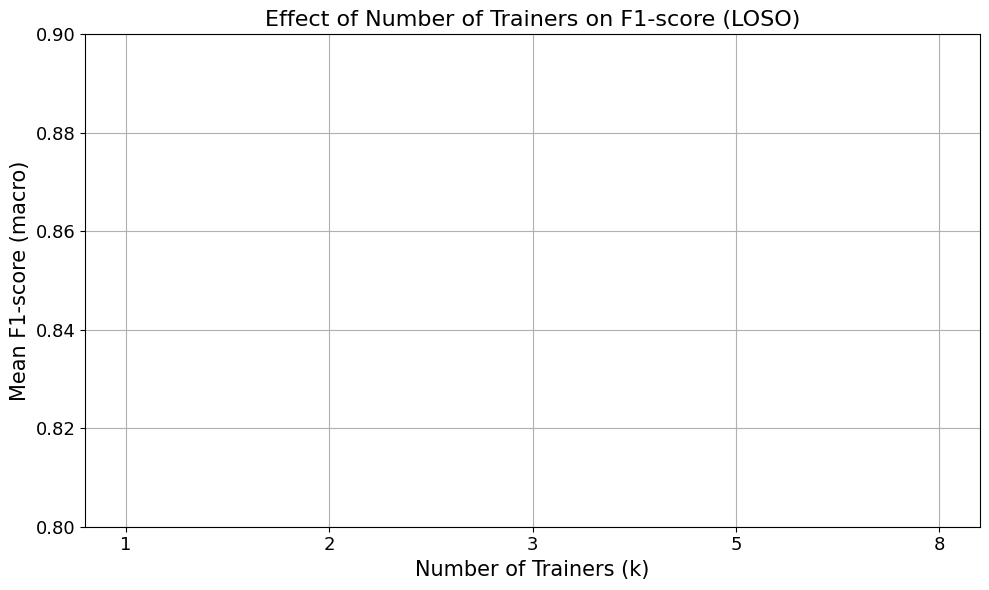

In [17]:
# k_trainersを横軸、f1_meanを縦軸にした折れ線グラフをプロット　x軸は等間隔にする
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(
    range(len(summary_df["k_trainers"])),
    summary_df["f1_mean"],
    marker='o'
)
plt.xlabel('Number of Trainers (k)', fontsize=15)
plt.ylabel('Mean F1-score (macro)', fontsize=15)
plt.title('Effect of Number of Trainers on F1-score (LOSO)', fontsize=16)
plt.xticks(range(len(summary_df["k_trainers"])), summary_df["k_trainers"], fontsize=13)
plt.yticks(fontsize=13)
plt.ylim(0.8, 0.9)
plt.grid(True)
plt.tight_layout()
plt.show()


In [18]:
subjects = ["tanaka1","tanaka2","tuji1","tuji2","okawa1","okawa2","maeda1","maeda2"]

df_context = pd.DataFrame()

# 8人のうち、一人テスト対象、残り訓練者全員で試し、それぞれの結果を保存する
for test_target in subjects:
    train_keywords = [s for s in subjects if s != test_target]

    model, acc, pred, X_test, y_test, real_labels, feature_cols, acc_real = load_and_decision_tree2(
        test_target=test_target,
        keywords=train_keywords,   # ← ここが超重要
        test_ratio=1.0,
        # target_col="rf_class",
        target_col="xgb_class",
        n_estimators=10
    )

    print(f"[Final Test] test={test_target}  acc={acc_real:.3f}")

    df_context= pd.concat([df_context,
        pd.DataFrame({
            "test_target": test_target,
            "pred": pred,
            "real_labels": real_labels
        })
    ], axis=0, ignore_index=True)



Accuracy on real labels: 0.9318
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     11914
           1       0.94      0.70      0.80      2956

    accuracy                           0.93     14870
   macro avg       0.94      0.84      0.88     14870
weighted avg       0.93      0.93      0.93     14870

[Final Test] test=tanaka1  acc=0.932
Accuracy on real labels: 0.9484
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      9384
           1       0.97      0.79      0.87      2636

    accuracy                           0.95     12020
   macro avg       0.96      0.89      0.92     12020
weighted avg       0.95      0.95      0.95     12020

[Final Test] test=tanaka2  acc=0.948
Accuracy on real labels: 0.7560
              precision    recall  f1-score   support

           0       0.74      0.99      0.85      9144
           1       0.95      0.25      0.39      4256

    accuracy

In [19]:
# df_context.to_csv("results_context_final.csv", index=False)